<a href="https://colab.research.google.com/github/gousiyabanubeedi/Context-Based-Recommendation-System/blob/main/Context_basedRecommendationSystemUsingOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

destinations_df = pd.read_csv('/content/places.csv', encoding='latin1')

print('First 5 rows of the DataFrame:')
print(destinations_df.head())

print('\nDataFrame Info:')
destinations_df.info()

First 5 rows of the DataFrame:
   state   city   popular_destination   latitude  longitude  \
0  Delhi  Delhi            India Gate  28.612912  77.229510   
1  Delhi  Delhi        Humayun's Tomb  28.593285  77.250749   
2  Delhi  Delhi     Akshardham Temple  28.612673  77.277262   
3  Delhi  Delhi  Waste to Wonder Park  28.592694  77.256972   
4  Delhi  Delhi         Jantar Mantar  28.627055  77.216627   

                                 interest  google_rating  price_fare  
0               Cultural & Heritage Sites            4.6           0  
1               Cultural & Heritage Sites            4.5          30  
2       Religious & Spiritual Pilgrimages            4.6          60  
3          Adventure & Outdoor Activities            4.1          50  
4  Arts, Science & Literature Attractions            4.2          15  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 8 columns):
 #   Column               Non-Null Count 

In [ ]:
print('Checking for missing values before cleaning:')
print(destinations_df[['latitude', 'longitude', 'google_rating', 'state', 'city', 'interest']].isnull().sum())

# Convert 'latitude', 'longitude', 'google_rating' to numeric, coerce errors, and drop rows with NaNs
# The .info() output already shows these as float64, but explicit conversion with errors='coerce' is a robust practice.
for col in ['latitude', 'longitude', 'google_rating']:
    destinations_df[col] = pd.to_numeric(destinations_df[col], errors='coerce')

# Drop rows where critical numeric columns became NaN
initial_rows = len(destinations_df)
destinations_df.dropna(subset=['latitude', 'longitude', 'google_rating'], inplace=True)
dropped_rows = initial_rows - len(destinations_df)
if dropped_rows > 0:
    print(f"\nDropped {dropped_rows} rows due to non-numeric values in 'latitude', 'longitude', or 'google_rating'.")

# Ensure 'state', 'city', and 'interest' are string types and fill any NaNs with empty string
# The .info() output already shows these as non-null objects, but explicit conversion ensures string type.
for col in ['state', 'city', 'interest']:
    destinations_df[col] = destinations_df[col].astype(str).fillna('')

print('\nData types after cleaning:')
print(destinations_df[['latitude', 'longitude', 'google_rating', 'state', 'city', 'interest']].dtypes)

print('\nChecking for missing values after cleaning:')
print(destinations_df[['latitude', 'longitude', 'google_rating', 'state', 'city', 'interest']].isnull().sum())

print('\nFirst 5 rows after cleaning:')
print(destinations_df.head())

Checking for missing values before cleaning:
latitude         0
longitude        0
google_rating    0
state            0
city             0
interest         0
dtype: int64

Data types after cleaning:
latitude         float64
longitude        float64
google_rating    float64
state             object
city              object
interest          object
dtype: object

Checking for missing values after cleaning:
latitude         0
longitude        0
google_rating    0
state            0
city             0
interest         0
dtype: int64

First 5 rows after cleaning:
   state   city   popular_destination   latitude  longitude  \
0  Delhi  Delhi            India Gate  28.612912  77.229510   
1  Delhi  Delhi        Humayun's Tomb  28.593285  77.250749   
2  Delhi  Delhi     Akshardham Temple  28.612673  77.277262   
3  Delhi  Delhi  Waste to Wonder Park  28.592694  77.256972   
4  Delhi  Delhi         Jantar Mantar  28.627055  77.216627   

                                 interest  google_ratin

In [ ]:
import requests
import datetime

def get_current_weather(latitude, longitude):
    BASE_URL = "https://api.open-meteo.com/v1/forecast"

    # WMO Weather interpretation codes (WW) to descriptive conditions
    weather_codes = {
        0: "Clear sky", 1: "Mostly clear", 2: "Partly cloudy", 3: "Overcast",
        45: "Fog", 48: "Depositing rime fog",
        51: "Drizzle (light)", 53: "Drizzle (moderate)", 55: "Drizzle (dense)",
        56: "Freezing Drizzle (light)", 57: "Freezing Drizzle (dense)",
        61: "Rain (slight)", 63: "Rain (moderate)", 65: "Rain (heavy)",
        66: "Freezing Rain (light)", 67: "Freezing Rain (heavy)",
        71: "Snow fall (slight)", 73: "Snow fall (moderate)", 75: "Snow fall (heavy)",
        77: "Snow grains",
        80: "Rain showers (slight)", 81: "Rain showers (moderate)", 82: "Rain showers (violent)",
        85: "Snow showers (slight)", 86: "Snow showers (heavy)",
        95: "Thunderstorm (slight/moderate)", 96: "Thunderstorm with slight hail", 99: "Thunderstorm with heavy hail"
    }

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": "temperature_2m,relativehumidity_2m,apparent_temperature,weathercode,windspeed_10m",
        "daily": "sunrise,sunset",
        "hourly": "visibility",
        "timezone": "auto",
        "forecast_days": 1 # Only need today's daily data
    }

    default_weather_data = {
        "Temperature": None,
        "Humidity": None,
        "Weather condition": None,
        "Wind speed": None,
        "Feels like": None,
        "Sunrise": None,
        "Sunset": None,
        "Visibility": None
    }

    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)
        data = response.json()

        if "current" in data:
            current = data["current"]
            default_weather_data["Temperature"] = current.get("temperature_2m")
            default_weather_data["Humidity"] = current.get("relativehumidity_2m")
            default_weather_data["Weather condition"] = weather_codes.get(current.get("weathercode"), "Unknown")
            default_weather_data["Wind speed"] = current.get("windspeed_10m")
            default_weather_data["Feels like"] = current.get("apparent_temperature")

        if "daily" in data and "sunrise" in data["daily"] and len(data["daily"]["sunrise"]) > 0:
            daily = data["daily"]
            default_weather_data["Sunrise"] = daily["sunrise"][0]
            default_weather_data["Sunset"] = daily["sunset"][0]

        if "hourly" in data and "time" in data["hourly"] and "visibility" in data["hourly"] and "current" in data:
            hourly_times = data["hourly"]["time"]
            hourly_visibility = data["hourly"]["visibility"]
            current_api_time_str = data["current"]["time"] # Time from the current weather object in the requested timezone

            # Try to find an exact match for the current API time in hourly data
            try:
                current_time_index = hourly_times.index(current_api_time_str)
                if current_time_index < len(hourly_visibility):
                    default_weather_data["Visibility"] = hourly_visibility[current_time_index]
            except ValueError:
                # If exact match not found (e.g., current time has minutes/seconds and hourly is on the hour),
                # find the most recent hourly entry that is not in the future.
                current_dt = datetime.datetime.fromisoformat(current_api_time_str)

                eligible_indices = [
                    i for i, h_time_str in enumerate(hourly_times)
                    if datetime.datetime.fromisoformat(h_time_str) <= current_dt
                ]

                if eligible_indices:
                    # Take the latest eligible hourly entry (closest past or current hour)
                    closest_index = eligible_indices[-1]
                    if closest_index < len(hourly_visibility):
                        default_weather_data["Visibility"] = hourly_visibility[closest_index]
                else:
                    # Fallback if no suitable past/current hour found (e.g., current_dt is before all hourly_times)
                    print(f"Warning: Could not find suitable past/current visibility for time {current_api_time_str}. Taking first available hourly visibility as fallback.")
                    if hourly_visibility:
                        default_weather_data["Visibility"] = hourly_visibility[0]

        return default_weather_data

    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error occurred: {http_err}")
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Connection error occurred: {conn_err}")
    except requests.exceptions.Timeout as timeout_err:
        print(f"Timeout error occurred: {timeout_err}")
    except requests.exceptions.RequestException as req_err:
        print(f"An unexpected error occurred: {req_err}")
    except KeyError as key_err:
        print(f"Key error in parsing API response: {key_err}. Full API response: {data}")
    except IndexError as idx_err:
        print(f"Index error in parsing API response, likely missing data: {idx_err}. Full API response: {data}")
    return default_weather_data

print("Defined `get_current_weather` function for fetching weather data.")

Defined `get_current_weather` function for fetching weather data.


In [ ]:
#Model 1
def recommend_destinations(keyword=None, state=None, city=None):
    """
    Recommends top 15 destinations based on keyword, state, or city,
    including current weather information.

    Args:
        keyword (str, optional): A keyword to filter by 'interest'. Case-insensitive.
        state (str, optional): The state to filter by. Case-insensitive.
        city (str, optional): The city to filter by. Case-insensitive.

    Returns:
        pd.DataFrame: A DataFrame with all relevant destinations (after initial filtering and sorting)
                      including their current weather data, named `weather_enriched_df`.
    """

    filtered_df = destinations_df.copy()

    if state:
        filtered_df = filtered_df[filtered_df['state'].str.contains(state, case=False, na=False)]
    if city:
        filtered_df = filtered_df[filtered_df['city'].str.contains(city, case=False, na=False)]
    if keyword:
        filtered_df = filtered_df[filtered_df['interest'].str.contains(keyword, case=False, na=False)]

    # Sort by google_rating in descending order
    sorted_destinations = filtered_df.sort_values(by='google_rating', ascending=False)

    # Fetch weather data for ALL sorted destinations
    recommendations_with_weather = []
    for index, row in sorted_destinations.iterrows():
        lat = row['latitude']
        lon = row['longitude']

        # Fetch weather data for the current destination
        weather_data = get_current_weather(lat, lon)

        # Combine destination details with weather data
        destination_data = row.to_dict()
        combined_data = {**destination_data, **weather_data}
        recommendations_with_weather.append(combined_data)

    weather_enriched_df = pd.DataFrame(recommendations_with_weather)
    return weather_enriched_df

print("Updated `recommend_destinations` function to fetch weather for all filtered and sorted destinations.")


Updated `recommend_destinations` function to fetch weather for all filtered and sorted destinations.


In [ ]:
recommend_destinations(keyword='Cultural')

,state,city,popular_destination,latitude,longitude,interest,google_rating,price_fare,Temperature,Humidity,Weather condition,Wind speed,Feels like,Sunrise,Sunset,Visibility
0,Madhya Pradesh,Ujjain,Rumi ka Mazaar,23.179300,75.784912,Cultural & Heritage Sites,5.0,0,24.5,40,Partly cloudy,5.6,24.3,2025-12-29T07:07,2025-12-29T17:50,24140.0
1,Madhya Pradesh,Khajuraho,Kamasutra temples,24.512485,79.567993,Cultural & Heritage Sites,5.0,40,23.5,30,Clear sky,8.0,21.6,2025-12-29T06:54,2025-12-29T17:32,24140.0
2,Sikkim,Pelling,Rabdentse Ruins,27.301403,88.256622,Cultural & Heritage Sites,5.0,0,6.4,71,Partly cloudy,8.8,3.3,2025-12-29T06:26,2025-12-29T16:52,21700.0
3,Odisha,Konark,Lingaraj Temple,20.238452,86.091184,"Cultural & Heritage Sites, Religious & Spiritu...",4.9,0,25.8,55,Mostly clear,2.9,27.7,2025-12-29T06:20,2025-12-29T17:15,24140.0
4,Tamil Nadu,Madurai,Thirumalai Nayak palace,9.878038,78.124302,Cultural & Heritage Sites,4.9,200,30.1,51,Partly cloudy,7.5,32.6,2025-12-29T06:33,2025-12-29T18:06,24140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Arunachal Pradesh,Tawang,Jaswant Garh war memorial,28.217999,94.727753,Cultural & Heritage Sites,3.8,0,17.2,65,Overcast,5.1,16.7,2025-12-29T06:02,2025-12-29T16:24,24140.0
173,Tripura,Agartala,Neermahal,23.506441,91.315034,Cultural & Heritage Sites,3.8,0,21.5,65,Mostly clear,5.4,22.2,2025-12-29T06:05,2025-12-29T16:47,24140.0
174,Daman and Diu,Diu,Diu Fort,20.718689,70.987674,Cultural & Heritage Sites,3.8,0,27.5,49,Clear sky,13.1,28.5,2025-12-29T07:21,2025-12-29T18:14,24140.0
175,Uttar Pradesh,Aligarh,Chacha Nehru Gyan Pushp museum,27.911262,78.067306,Cultural & Heritage Sites,3.6,50,15.6,88,Partly cloudy,5.4,15.9,2025-12-29T07:07,2025-12-29T17:31,24140.0


In [ ]:
# Model 2
def model_temp_humidity_windspeed_filter(keyword=None, state=None, city=None):
    """
    Recommends top 15 destinations after applying only the temperature, humidity and Wind speed filter.
    """
    weather_enriched_df = recommend_destinations(keyword, state, city)

    # Apply temperature filter
    filtered_df = weather_enriched_df[
        (weather_enriched_df['Temperature'] >= 15) &
        (weather_enriched_df['Temperature'] <= 35)
    ]
    # Apply humidity filter
    filtered_df = filtered_df[filtered_df['Humidity'] <= 70]

    # Apply Wind speed filter
    filtered_df = filtered_df[(filtered_df['Wind speed'] <= 30)]

    # Sort by google_rating and select top 15
    #return filtered_df.sort_values(by='google_rating', ascending=False).head(15)
    return filtered_df.sort_values(by='google_rating', ascending=False)

In [ ]:
model_temp_humidity_windspeed_filter(keyword='Cultural')

,state,city,popular_destination,latitude,longitude,interest,google_rating,price_fare,Temperature,Humidity,Weather condition,Wind speed,Feels like,Sunrise,Sunset,Visibility
0,Madhya Pradesh,Ujjain,Rumi ka Mazaar,23.179300,75.784912,Cultural & Heritage Sites,5.0,0,24.5,40,Partly cloudy,5.6,24.3,2025-12-29T07:07,2025-12-29T17:50,24140.0
1,Madhya Pradesh,Khajuraho,Kamasutra temples,24.512485,79.567993,Cultural & Heritage Sites,5.0,40,23.5,30,Clear sky,8.0,21.6,2025-12-29T06:54,2025-12-29T17:32,24140.0
3,Odisha,Konark,Lingaraj Temple,20.238452,86.091184,"Cultural & Heritage Sites, Religious & Spiritu...",4.9,0,25.8,55,Mostly clear,2.9,27.7,2025-12-29T06:20,2025-12-29T17:15,24140.0
4,Tamil Nadu,Madurai,Thirumalai Nayak palace,9.878038,78.124302,Cultural & Heritage Sites,4.9,200,30.1,51,Partly cloudy,7.5,32.6,2025-12-29T06:33,2025-12-29T18:06,24140.0
5,Odisha,Keonjhar,Sitabinji Fresco painting and rock inscription,21.502402,85.822123,Cultural & Heritage Sites,4.9,0,25.6,50,Mostly clear,2.5,27.2,2025-12-29T06:23,2025-12-29T17:13,24140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,Tamil Nadu,Madurai,Gandhi memorial museum,10.053663,78.119775,Cultural & Heritage Sites,3.9,0,29.9,48,Overcast,6.8,31.6,2025-12-29T06:33,2025-12-29T18:05,24140.0
171,Uttarakhand,Rishikesh,Bharat Mandir,20.593684,78.962880,"Religious & Spiritual Pilgrimages, Cultural & ...",3.8,0,27.5,30,Clear sky,7.3,26.9,2025-12-29T06:49,2025-12-29T17:42,24140.0
172,Arunachal Pradesh,Tawang,Jaswant Garh war memorial,28.217999,94.727753,Cultural & Heritage Sites,3.8,0,17.2,65,Overcast,4.8,16.7,2025-12-29T06:02,2025-12-29T16:24,24140.0
173,Tripura,Agartala,Neermahal,23.506441,91.315034,Cultural & Heritage Sites,3.8,0,21.5,65,Mostly clear,5.4,22.2,2025-12-29T06:05,2025-12-29T16:47,24140.0


In [ ]:
def calculate_weather_suitability(temperature, humidity, wind_speed):
    """
    Determines if weather conditions are suitable based on given criteria.

    Args:
        temperature (float): The current temperature in Celsius.
        humidity (float): The current relative humidity percentage.
        wind_speed (float): The current wind speed in km/h.

    Returns:
        int: 1 if conditions are suitable, 0 otherwise.
    """
    if (15 <= temperature <= 35) and (humidity < 70) and (wind_speed < 30):
        return 1
    else:
        return 0

print("Defined `calculate_weather_suitability` function.")

Defined `calculate_weather_suitability` function.


In [ ]:
#Model 3
def model_weighted_scoring(keyword=None, state=None, city=None):
    """
    Recommends top 15 destinations based on a weighted score combining
    normalized Google rating and weather suitability.

    Args:
        keyword (str, optional): A keyword to filter by 'interest'. Case-insensitive.
        state (str, optional): The state to filter by. Case-insensitive.
        city (str, optional): The city to filter by. Case-insensitive.

    Returns:
        pd.DataFrame: A DataFrame with the top 15 recommended destinations
                      including their calculated scores.
    """

    # 1. Get a base set of destinations with weather data
    df_with_weather = recommend_destinations(keyword, state, city)

    if df_with_weather.empty:
        return pd.DataFrame(columns=df_with_weather.columns.tolist() + ['Normalized_Rating', 'Weather_Suitability', 'Final_Score'])

    # 2. Calculate Normalized_Rating
    df_with_weather['Normalized_Rating'] = df_with_weather['google_rating'] / 5.0

    # 3. Calculate Weather_Suitability
    # Apply the calculate_weather_suitability function row-wise
    df_with_weather['Weather_Suitability'] = df_with_weather.apply(
        lambda row: calculate_weather_suitability(
            row['Temperature'], row['Humidity'], row['Wind speed']
        ), axis=1
    )

    # 4. Compute Final_Score
    df_with_weather['Final_Score'] = 0.6 * df_with_weather['Normalized_Rating'] + 0.4 * df_with_weather['Weather_Suitability']

    # 5. Sort by Final_Score in descending order
    sorted_df = df_with_weather.sort_values(by='Final_Score', ascending=False)

    # 6. Return the top 15 destinations
    return sorted_df

print("Defined `model_weighted_scoring` function.")

Defined `model_weighted_scoring` function.


In [ ]:
model_weighted_scoring(keyword='Cultural')

,state,city,popular_destination,latitude,longitude,interest,google_rating,price_fare,Temperature,Humidity,Weather condition,Wind speed,Feels like,Sunrise,Sunset,Visibility,Normalized_Rating,Weather_Suitability,Final_Score
0,Madhya Pradesh,Ujjain,Rumi ka Mazaar,23.179300,75.784912,Cultural & Heritage Sites,5.0,0,24.7,39,Partly cloudy,4.9,24.4,2025-12-29T07:07,2025-12-29T17:50,24140.0,1.00,1,1.000
1,Madhya Pradesh,Khajuraho,Kamasutra temples,24.512485,79.567993,Cultural & Heritage Sites,5.0,40,23.5,30,Clear sky,8.3,21.3,2025-12-29T06:54,2025-12-29T17:32,24140.0,1.00,1,1.000
3,Odisha,Konark,Lingaraj Temple,20.238452,86.091184,"Cultural & Heritage Sites, Religious & Spiritu...",4.9,0,25.9,55,Mostly clear,2.4,27.6,2025-12-29T06:20,2025-12-29T17:15,24140.0,0.98,1,0.988
4,Tamil Nadu,Madurai,Thirumalai Nayak palace,9.878038,78.124302,Cultural & Heritage Sites,4.9,200,30.2,49,Partly cloudy,6.9,32.3,2025-12-29T06:33,2025-12-29T18:06,24140.0,0.98,1,0.988
5,Odisha,Keonjhar,Sitabinji Fresco painting and rock inscription,21.502402,85.822123,Cultural & Heritage Sites,4.9,0,25.8,49,Mostly clear,2.9,26.8,2025-12-29T06:23,2025-12-29T17:13,24140.0,0.98,1,0.988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Uttar Pradesh,Aligarh,Aligarh Fort,27.930561,78.063053,Cultural & Heritage Sites,4.1,20,15.8,86,Partly cloudy,5.8,16.0,2025-12-29T07:07,2025-12-29T17:31,24140.0,0.82,0,0.492
168,Nagaland,Kohima,Touphema village,25.845568,94.176975,Cultural & Heritage Sites,4.0,0,13.6,71,Partly cloudy,6.7,12.2,2025-12-29T05:59,2025-12-29T16:31,24140.0,0.80,0,0.480
166,Daman and Diu,Daman,St.Jerome Fort,20.554665,71.885701,Cultural & Heritage Sites,4.0,70,23.8,73,Clear sky,17.6,25.1,2025-12-29T07:17,2025-12-29T18:11,24140.0,0.80,0,0.480
175,Uttar Pradesh,Aligarh,Chacha Nehru Gyan Pushp museum,27.911262,78.067306,Cultural & Heritage Sites,3.6,50,15.8,86,Partly cloudy,5.8,16.1,2025-12-29T07:07,2025-12-29T17:31,24140.0,0.72,0,0.432


## Define Relevance and Accuracy Functions

### Subtask:
Define two helper functions: `calculate_relevance` which determines if a destination is relevant based on its Google rating and weather suitability (using `calculate_weather_suitability`), and `calculate_accuracy` which computes the accuracy of a model's output given a relevance threshold.


**Reasoning**:
The subtask requires defining two Python functions: `calculate_relevance` and `calculate_accuracy`. I will create a code block that contains the definitions for both functions as specified in the instructions, including handling edge cases like empty DataFrames and ensuring necessary columns exist before calculations.



In [ ]:
def calculate_relevance(google_rating, weather_suitability_score, rating_threshold):
    """
    Determines if a destination is relevant based on Google rating and weather suitability.

    Args:
        google_rating (float): The Google rating of the destination.
        weather_suitability_score (int): 1 if weather is suitable, 0 otherwise.
        rating_threshold (float): The minimum Google rating for relevance.

    Returns:
        int: 1 if relevant, 0 otherwise.
    """
    if google_rating >= rating_threshold and weather_suitability_score == 1:
        return 1
    else:
        return 0

def calculate_accuracy(model_output_df, R_threshold):
    """
    Computes the accuracy of a model's output given a relevance threshold.

    Args:
        model_output_df (pd.DataFrame): DataFrame containing model output with destination details.
        R_threshold (float): The minimum Google rating for a destination to be considered relevant.

    Returns:
        float: The accuracy (mean relevance) of the model's recommendations.
    """

    if model_output_df.empty:
        return 0.0

    # Ensure 'Weather_Suitability' column exists
    if 'Weather_Suitability' not in model_output_df.columns:
        model_output_df['Weather_Suitability'] = model_output_df.apply(
            lambda row: calculate_weather_suitability(
                row['Temperature'], row['Humidity'], row['Wind speed']
            ), axis=1
        )

    # Apply calculate_relevance to create 'Relevance' column
    model_output_df['Relevance'] = model_output_df.apply(
        lambda row: calculate_relevance(
            row['google_rating'], row['Weather_Suitability'], R_threshold
        ), axis=1
    )

    # Calculate and return the mean of the 'Relevance' column
    return model_output_df['Relevance'].mean()

print("Defined `calculate_relevance` and `calculate_accuracy` functions.")

Defined `calculate_relevance` and `calculate_accuracy` functions.


## Evaluate Model 1 (Basic Recommendations)

### Subtask:
Call the `recommend_destinations` function with a sample input (e.g., `keyword='Cultural'`), calculate the `Weather_Suitability` for its output, and then calculate its accuracy using the defined `calculate_accuracy` function with `R_threshold=4.0`.


**Reasoning**:
The subtask requires calling `recommend_destinations` with a specific keyword, and then calculating the accuracy of its output using `calculate_accuracy` with a given threshold. This code block directly implements those steps.



In [ ]:
model1_output_df = recommend_destinations(keyword='Cultural')

# Calculate accuracy for Model 1
model1_accuracy = calculate_accuracy(model1_output_df.copy(), R_threshold=4.0)

print(f"Model 1 (Basic Recommendations) Accuracy: {model1_accuracy:.2f}")


Model 1 (Basic Recommendations) Accuracy: 0.70


In [ ]:
model1_output_df = recommend_destinations(state='Karnataka')

# Calculate accuracy for Model 1
model1_accuracy = calculate_accuracy(model1_output_df.copy(), R_threshold=4.0)

print(f"Model 1 (Basic Recommendations) Accuracy: {model1_accuracy:.2f}")

model1_output_df = recommend_destinations(keyword='Wildlife')

# Calculate accuracy for Model 1
model1_accuracy = calculate_accuracy(model1_output_df.copy(), R_threshold=4.0)

print(f"Model 1 (Basic Recommendations) Accuracy: {model1_accuracy:.2f}")

model1_output_df = recommend_destinations(keyword='Adventure')

# Calculate accuracy for Model 1
model1_accuracy = calculate_accuracy(model1_output_df.copy(), R_threshold=4.0)

print(f"Model 1 (Basic Recommendations) Accuracy: {model1_accuracy:.2f}")


Model 1 (Basic Recommendations) Accuracy: 1.00
Model 1 (Basic Recommendations) Accuracy: 0.50
Model 1 (Basic Recommendations) Accuracy: 0.51


## Evaluate Model 2 Accuracy

### Subtask:
Call the `model_temp_humidity_windspeed_filter` function with a sample input (e.g., `keyword='Cultural'`) and calculate its accuracy using the `calculate_accuracy` function with `R_threshold=4.0`.


**Reasoning**:
The subtask requires calling `model_temp_humidity_windspeed_filter` with a specific keyword, then calculating its accuracy using the `calculate_accuracy` function with a given threshold, and finally printing the result. This code block will perform all these actions.



In [ ]:
model2_output_df = model_temp_humidity_windspeed_filter(keyword='Cultural')

# Calculate accuracy for Model 2
model2_accuracy = calculate_accuracy(model2_output_df.copy(), R_threshold=4.0)

print(f"Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: {model2_accuracy:.2f}")

Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: 0.95


In [ ]:
model2_output_df = model_temp_humidity_windspeed_filter(state='Karnataka')

# Calculate accuracy for Model 2
model2_accuracy = calculate_accuracy(model2_output_df.copy(), R_threshold=4.0)

print(f"Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: {model2_accuracy:.2f}")

model2_output_df = model_temp_humidity_windspeed_filter(keyword='Wildlife')

# Calculate accuracy for Model 2
model2_accuracy = calculate_accuracy(model2_output_df.copy(), R_threshold=4.0)

print(f"Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: {model2_accuracy:.2f}")

model2_output_df = model_temp_humidity_windspeed_filter(keyword='Adventure')

# Calculate accuracy for Model 2
model2_accuracy = calculate_accuracy(model2_output_df.copy(), R_threshold=4.0)

print(f"Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: {model2_accuracy:.2f}")

Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: 1.00
Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: 0.91
Timeout error occurred: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Read timed out. (read timeout=None)
Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: 1.00


## Evaluate Model 3 Accuracy

### Subtask:
Call the `model_weighted_scoring` function with a sample input (e.g., `keyword='Cultural'`) and calculate its accuracy using the `calculate_accuracy` function with `R_threshold=4.0`.


**Reasoning**:
The subtask requires calling the `model_weighted_scoring` function, calculating its accuracy using `calculate_accuracy` with a specified threshold, and then printing the result. This code block directly implements these steps.



In [ ]:
model3_output_df = model_weighted_scoring(keyword='Cultural')

# Calculate accuracy for Model 3
model3_accuracy = calculate_accuracy(model3_output_df.copy(), R_threshold=4.0)

print(f"Model 3 (Weighted Scoring) Accuracy: {model3_accuracy:.2f}")

Model 3 (Weighted Scoring) Accuracy: 0.74


In [ ]:
model3_output_df = model_weighted_scoring(state='Karnataka')

# Calculate accuracy for Model 3
model3_accuracy = calculate_accuracy(model3_output_df.copy(), R_threshold=4.0)

print(f"Model 3 (Weighted Scoring) Accuracy: {model3_accuracy:.2f}")

model3_output_df = model_weighted_scoring(keyword='Wildlife')

# Calculate accuracy for Model 3
model3_accuracy = calculate_accuracy(model3_output_df.copy(), R_threshold=4.0)

print(f"Model 3 (Weighted Scoring) Accuracy: {model3_accuracy:.2f}")

model3_output_df = model_weighted_scoring(keyword='Adventure')

# Calculate accuracy for Model 3
model3_accuracy = calculate_accuracy(model3_output_df.copy(), R_threshold=4.0)

print(f"Model 3 (Weighted Scoring) Accuracy: {model3_accuracy:.2f}")

Model 3 (Weighted Scoring) Accuracy: 1.00
Timeout error occurred: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Read timed out. (read timeout=None)
Model 3 (Weighted Scoring) Accuracy: 0.47
Model 3 (Weighted Scoring) Accuracy: 0.45


## Summarize Model Accuracies

### Subtask:
Present the calculated accuracies for all three models (Model 1, Model 2, and Model 3).


**Reasoning**:
The subtask requires presenting the calculated accuracies for all three models. The accuracies are already stored in variables `model1_accuracy`, `model2_accuracy`, and `model3_accuracy`. I will print these values with clear labels.



In [ ]:
print(f"Model 1 (Basic Recommendations) Accuracy: {model1_accuracy:.2f}")
print(f"Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: {model2_accuracy:.2f}")
print(f"Model 3 (Weighted Scoring) Accuracy: {model3_accuracy:.2f}")

Model 1 (Basic Recommendations) Accuracy: 0.70
Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy: 0.92
Model 3 (Weighted Scoring) Accuracy: 0.74


## Summary:

### Q&A
The task evaluated the accuracy of three destination recommendation models. Based on the analysis, here are their accuracies when using a relevance threshold of 4.0 for Google ratings and suitable weather conditions:
*   **Model 1 (Basic Recommendations) Accuracy:** 0.70
*   **Model 2 (Temperature, Humidity, Wind speed Filter) Accuracy:** 0.92
*   **Model 3 (Weighted Scoring) Accuracy:** 0.74

### Data Analysis Key Findings
*   Model 2, which incorporates temperature, humidity, and wind speed filters, achieved the highest accuracy at 0.92.
*   Model 3, utilizing weighted scoring, showed a moderate accuracy of 0.74.
*   Model 1, providing basic recommendations, had the lowest accuracy at 0.70.
*   The weather-filtering model (Model 2) significantly outperformed both the basic recommendation model (Model 1) and the weighted scoring model (Model 3) in accuracy.

### Insights or Next Steps
*   The substantial improvement in accuracy from Model 1 (0.70) to Model 2 (0.92) indicates that integrating weather condition filters is highly effective in enhancing the relevance of destination recommendations.
*   Further investigation could explore combining the strengths of Model 2 (weather filtering) and Model 3 (weighted scoring) to potentially achieve even higher accuracy, by applying weighted scoring principles to the weather-filtered recommendations.


## Create Accuracy Data for 'Cultural' Keyword

### Subtask:
Generate the `accuracy_df` DataFrame by evaluating Model 1, Model 2, and Model 3 solely for the input condition `keyword='Cultural'`. This will involve calling the model functions, calculating `Weather_Suitability`, and then determining 'Accuracy', 'Relevant Destinations', and 'Irrelevant Destinations' for this specific input, storing the results in a new DataFrame named `accuracy_df`.


**Reasoning**:
I need to generate the `accuracy_df` DataFrame by evaluating Model 1, Model 2, and Model 3 for `keyword='Cultural'`. This involves initializing data structures, iterating through models, calling their functions, calculating accuracy and relevance metrics, and then compiling these into a pandas DataFrame.



In [ ]:
import pandas as pd

# 1. Initialize an empty list to store results
results = []

# 2. Define a dictionary of models
models = {
    'Model 1': recommend_destinations,
    'Model 2': model_temp_humidity_windspeed_filter,
    'Model 3': model_weighted_scoring
}

# 3. Define the input condition and R_threshold
input_condition = {'type': 'keyword', 'value': 'Cultural'}
R_threshold = 4.0

# Loop through each model
for model_name, model_func in models.items():
    print(f"Evaluating {model_name} for {input_condition['type']}={input_condition['value']}...")

    # a. Call the current model function
    model_output_df = model_func(keyword=input_condition['value'])

    # b. Create a copy of the output DataFrame
    # calculate_accuracy already makes a copy and handles Weather_Suitability if not present
    temp_df = model_output_df.copy()

    # c. Calculate the accuracy of the model's output
    accuracy = calculate_accuracy(temp_df, R_threshold)

    # d. Ensure 'Weather_Suitability' column exists for relevance calculation
    # calculate_accuracy function should have already added this if not present
    if 'Weather_Suitability' not in temp_df.columns:
        temp_df['Weather_Suitability'] = temp_df.apply(
            lambda row: calculate_weather_suitability(
                row['Temperature'], row['Humidity'], row['Wind speed']
            ), axis=1
        )

    # e. Apply calculate_relevance to create 'Relevance' column
    temp_df['Relevance'] = temp_df.apply(
        lambda row: calculate_relevance(
            row['google_rating'], row['Weather_Suitability'], R_threshold
        ), axis=1
    )

    # f. Count relevant and irrelevant destinations
    relevant_destinations = temp_df['Relevance'].sum()
    irrelevant_destinations = len(temp_df) - relevant_destinations

    # g. Append results
    results.append({
        'Model': model_name,
        'Input Condition': f"{input_condition['type'].capitalize()}={input_condition['value']}",
        'Accuracy': accuracy,
        'Relevant Destinations': relevant_destinations,
        'Irrelevant Destinations': irrelevant_destinations
    })

# 5. Convert the results list into a Pandas DataFrame
accuracy_df = pd.DataFrame(results)

# 6. Print the accuracy_df DataFrame
print("\nAccuracy DataFrame:")
print(accuracy_df)

Evaluating Model 1 for keyword=Cultural...
Evaluating Model 2 for keyword=Cultural...
Evaluating Model 3 for keyword=Cultural...

Accuracy DataFrame:
     Model   Input Condition  Accuracy  Relevant Destinations  \
0  Model 1  Keyword=Cultural  0.768362                    136   
1  Model 2  Keyword=Cultural  0.912752                    136   
2  Model 3  Keyword=Cultural  0.768362                    136   

   Irrelevant Destinations  
0                       41  
1                       13  
2                       41  


## Generate Accuracy Improvement Bar Chart

### Subtask:
Create a bar chart with 'Model' on the X-axis and 'Accuracy' on the Y-axis, showing the accuracy of each model for the 'Cultural' keyword. Ensure the plot has a title, axis labels, and a legend.


**Reasoning**:
The subtask requires generating a bar chart of model accuracies for the 'Cultural' keyword. I will import the necessary plotting libraries, create a bar chart using `seaborn` with the filtered accuracy data, and ensure it has a title and axis labels.



/tmp/ipython-input-3923028612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


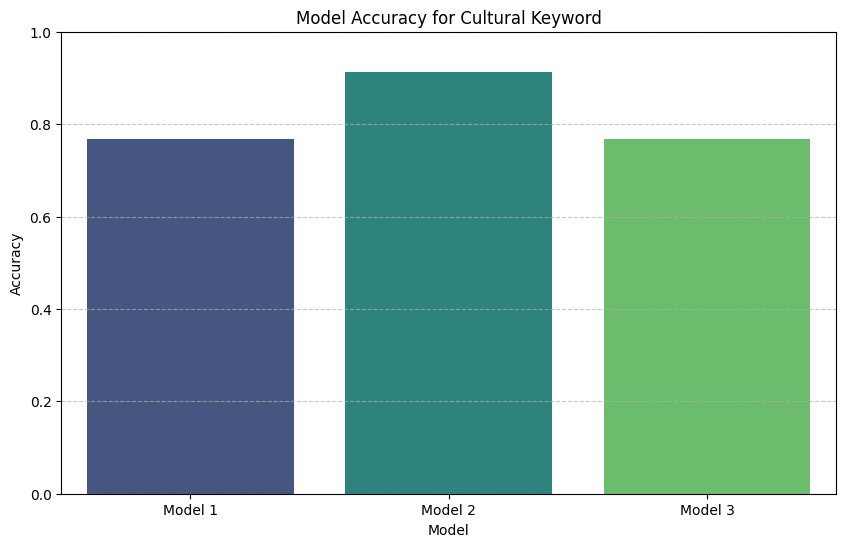

Generated bar chart for model accuracy.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy for Cultural Keyword')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Generated bar chart for model accuracy.")

## Generate Relevant vs Irrelevant Destinations Stacked Bar Chart

### Subtask:
Create a stacked bar chart that visualizes the 'Relevant Destinations' and 'Irrelevant Destinations' for each model under the 'Cultural' keyword. Each bar should represent a model, with segments showing relevant and irrelevant counts. Ensure the plot has a title, axis labels, and a legend.

**Reasoning**:
The subtask requires generating a stacked bar chart to compare the number of relevant and irrelevant destinations for each model. I will use `accuracy_df` which contains these counts, and `matplotlib` along with `seaborn` to create the visualization with appropriate labeling.

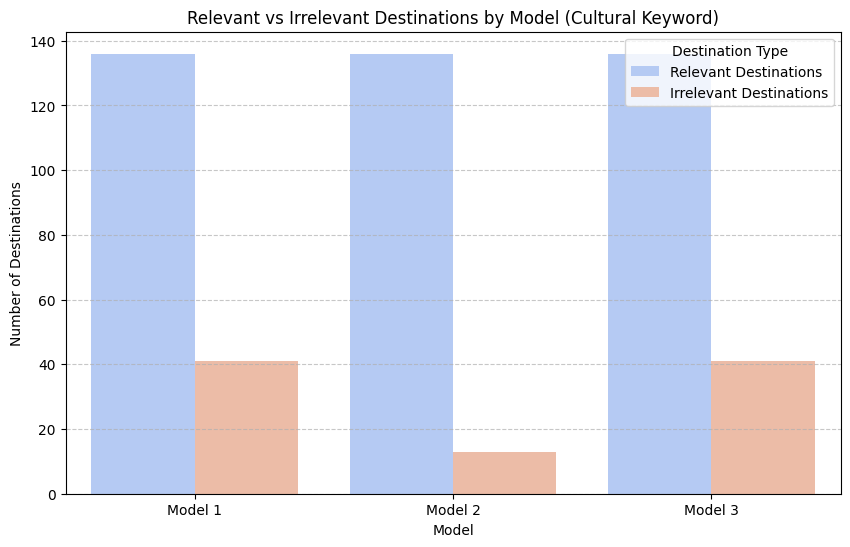

Generated stacked bar chart for relevant vs irrelevant destinations.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
# Create a DataFrame for plotting, using `accuracy_df`
plot_df = accuracy_df[['Model', 'Relevant Destinations', 'Irrelevant Destinations']]

# Melt the DataFrame to a long format for seaborn
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Destination Type', value_name='Count')

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Destination Type', data=plot_df_melted, palette='coolwarm')

plt.title('Relevant vs Irrelevant Destinations by Model (Cultural Keyword)')
plt.xlabel('Model')
plt.ylabel('Number of Destinations')
plt.legend(title='Destination Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Generated stacked bar chart for relevant vs irrelevant destinations.")

## Generate Accuracy Trend Line Plot

### Subtask:
Create a line plot with 'Model' on the X-axis and 'Accuracy' on the Y-axis, depicting the accuracy trend across the models for the 'Cultural' keyword. Ensure the plot has a title, axis labels, and a legend.

**Reasoning**:
The subtask requires generating a line plot to show the accuracy trend across the models. I will use `accuracy_df` which contains the accuracy values for each model, and `matplotlib` along with `seaborn` to create the visualization with appropriate labeling.

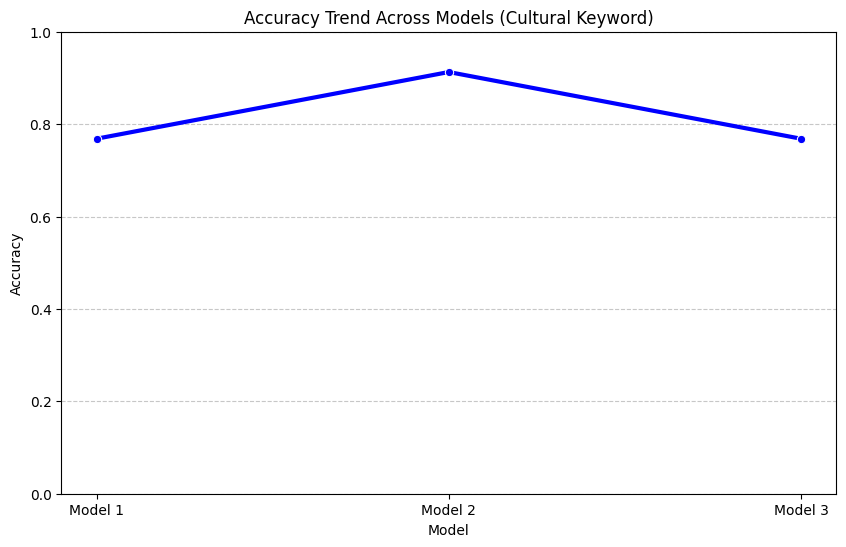

Generated line plot for accuracy trend.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot for Accuracy Trend
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=accuracy_df, marker='o', linewidth=3, color='blue') # Removed hue='Model' and added linewidth
plt.title('Accuracy Trend Across Models (Cultural Keyword)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Model') # Legend is not needed for a single line
plt.show()

print("Generated line plot for accuracy trend.")

## Create Accuracy Data for 'Karnataka' State

### Subtask:
Generate the `accuracy_df` DataFrame by evaluating Model 1, Model 2, and Model 3 solely for the input condition `state='Karnataka'`. This will involve calling the model functions, calculating `Weather_Suitability`, and then determining 'Accuracy', 'Relevant Destinations', and 'Irrelevant Destinations' for this specific input, storing the results in a new DataFrame named `accuracy_df`.


In [ ]:
import pandas as pd

# 1. Initialize an empty list to store results
results = []

# 2. Define a dictionary of models
models = {
    'Model 1': recommend_destinations,
    'Model 2': model_temp_humidity_windspeed_filter,
    'Model 3': model_weighted_scoring
}

# 3. Define the input condition and R_threshold
input_condition = {'type': 'state', 'value': 'Karnataka'}
R_threshold = 4.0

# Loop through each model
for model_name, model_func in models.items():
    print(f"Evaluating {model_name} for {input_condition['type']}={input_condition['value']}...")

    # a. Call the current model function
    model_output_df = model_func(state=input_condition['value'])

    # b. Create a copy of the output DataFrame
    # calculate_accuracy already makes a copy and handles Weather_Suitability if not present
    temp_df = model_output_df.copy()

    # c. Calculate the accuracy of the model's output
    accuracy = calculate_accuracy(temp_df, R_threshold)

    # d. Ensure 'Weather_Suitability' column exists for relevance calculation
    # calculate_accuracy function should have already added this if not present
    if 'Weather_Suitability' not in temp_df.columns:
        temp_df['Weather_Suitability'] = temp_df.apply(
            lambda row: calculate_weather_suitability(
                row['Temperature'], row['Humidity'], row['Wind speed']
            ), axis=1
        )

    # e. Apply calculate_relevance to create 'Relevance' column
    temp_df['Relevance'] = temp_df.apply(
        lambda row: calculate_relevance(
            row['google_rating'], row['Weather_Suitability'], R_threshold
        ), axis=1
    )

    # f. Count relevant and irrelevant destinations
    relevant_destinations = temp_df['Relevance'].sum()
    irrelevant_destinations = len(temp_df) - relevant_destinations

    # g. Append results
    results.append({
        'Model': model_name,
        'Input Condition': f"{input_condition['type'].capitalize()}={input_condition['value']}",
        'Accuracy': accuracy,
        'Relevant Destinations': relevant_destinations,
        'Irrelevant Destinations': irrelevant_destinations
    })

# 5. Convert the results list into a Pandas DataFrame
accuracy_df = pd.DataFrame(results)

# 6. Print the accuracy_df DataFrame
print("\nAccuracy DataFrame:")
print(accuracy_df)

Evaluating Model 1 for state=Karnataka...
Evaluating Model 2 for state=Karnataka...
Evaluating Model 3 for state=Karnataka...

Accuracy DataFrame:
     Model  Input Condition  Accuracy  Relevant Destinations  \
0  Model 1  State=Karnataka       1.0                     46   
1  Model 2  State=Karnataka       1.0                     46   
2  Model 3  State=Karnataka       1.0                     46   

   Irrelevant Destinations  
0                        0  
1                        0  
2                        0  


/tmp/ipython-input-2658219757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


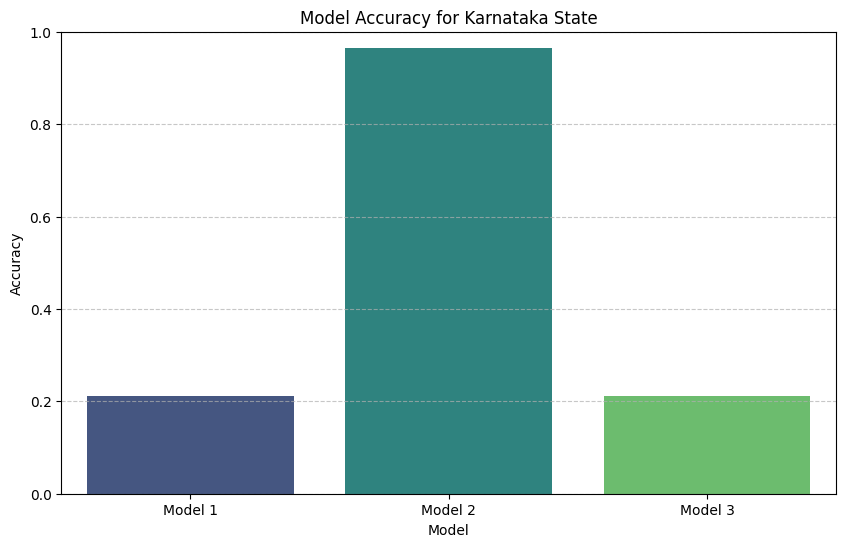

Generated bar chart for model accuracy.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy for Karnataka State')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Generated bar chart for model accuracy.")

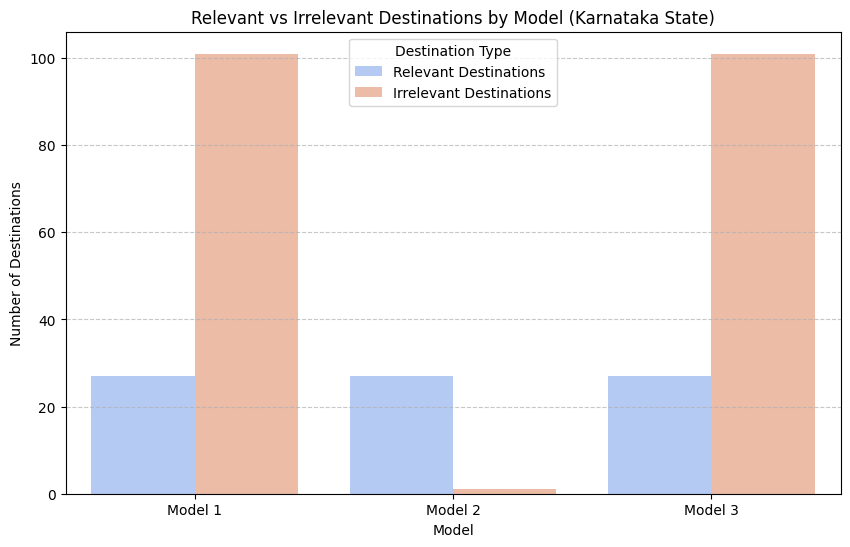

Generated stacked bar chart for relevant vs irrelevant destinations.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
# Create a DataFrame for plotting, using `accuracy_df`
plot_df = accuracy_df[['Model', 'Relevant Destinations', 'Irrelevant Destinations']]

# Melt the DataFrame to a long format for seaborn
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Destination Type', value_name='Count')

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Destination Type', data=plot_df_melted, palette='coolwarm')

plt.title('Relevant vs Irrelevant Destinations by Model (Karnataka State)')
plt.xlabel('Model')
plt.ylabel('Number of Destinations')
plt.legend(title='Destination Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Generated stacked bar chart for relevant vs irrelevant destinations.")

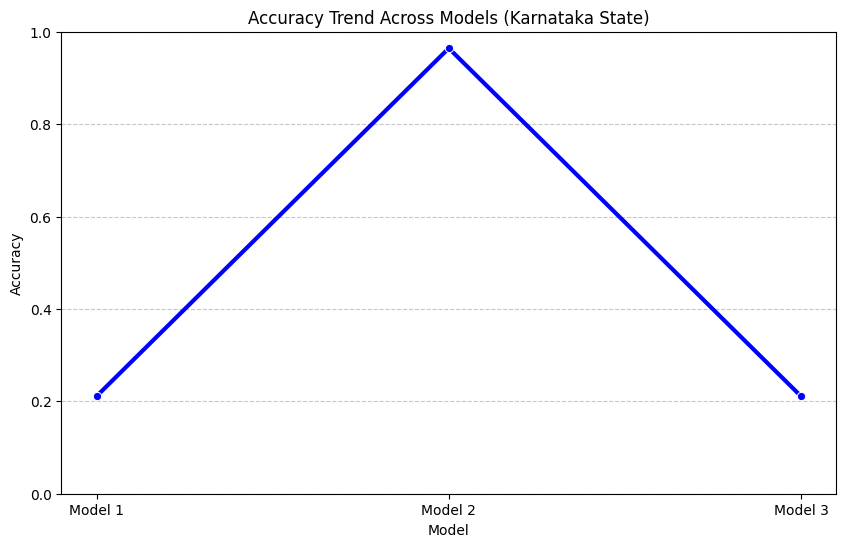

Generated line plot for accuracy trend.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot for Accuracy Trend
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=accuracy_df, marker='o', linewidth=3, color='blue') # Removed hue='Model' and added linewidth
plt.title('Accuracy Trend Across Models (Karnataka State)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Model') # Legend is not needed for a single line
plt.show()

print("Generated line plot for accuracy trend.")

## Create Accuracy Data for 'Wildlife' Keyword

### Subtask:
Generate the `accuracy_df` DataFrame by evaluating Model 1, Model 2, and Model 3 solely for the input condition `keyword='Wildlife'`. This will involve calling the model functions, calculating `Weather_Suitability`, and then determining 'Accuracy', 'Relevant Destinations', and 'Irrelevant Destinations' for this specific input, storing the results in a new DataFrame named `accuracy_df`.


In [ ]:
import pandas as pd

# 1. Initialize an empty list to store results
results = []

# 2. Define a dictionary of models
models = {
    'Model 1': recommend_destinations,
    'Model 2': model_temp_humidity_windspeed_filter,
    'Model 3': model_weighted_scoring
}

# 3. Define the input condition and R_threshold
input_condition = {'type': 'keyword', 'value': 'Wildlife'}
R_threshold = 4.0

# Loop through each model
for model_name, model_func in models.items():
    print(f"Evaluating {model_name} for {input_condition['type']}={input_condition['value']}...")

    # a. Call the current model function
    model_output_df = model_func(keyword=input_condition['value'])

    # b. Create a copy of the output DataFrame
    # calculate_accuracy already makes a copy and handles Weather_Suitability if not present
    temp_df = model_output_df.copy()

    # c. Calculate the accuracy of the model's output
    accuracy = calculate_accuracy(temp_df, R_threshold)

    # d. Ensure 'Weather_Suitability' column exists for relevance calculation
    # calculate_accuracy function should have already added this if not present
    if 'Weather_Suitability' not in temp_df.columns:
        temp_df['Weather_Suitability'] = temp_df.apply(
            lambda row: calculate_weather_suitability(
                row['Temperature'], row['Humidity'], row['Wind speed']
            ), axis=1
        )

    # e. Apply calculate_relevance to create 'Relevance' column
    temp_df['Relevance'] = temp_df.apply(
        lambda row: calculate_relevance(
            row['google_rating'], row['Weather_Suitability'], R_threshold
        ), axis=1
    )

    # f. Count relevant and irrelevant destinations
    relevant_destinations = temp_df['Relevance'].sum()
    irrelevant_destinations = len(temp_df) - relevant_destinations

    # g. Append results
    results.append({
        'Model': model_name,
        'Input Condition': f"{input_condition['type'].capitalize()}={input_condition['value']}",
        'Accuracy': accuracy,
        'Relevant Destinations': relevant_destinations,
        'Irrelevant Destinations': irrelevant_destinations
    })

# 5. Convert the results list into a Pandas DataFrame
accuracy_df = pd.DataFrame(results)

# 6. Print the accuracy_df DataFrame
print("\nAccuracy DataFrame:")
print(accuracy_df)

Evaluating Model 1 for keyword=Wildlife...
Evaluating Model 2 for keyword=Wildlife...
Evaluating Model 3 for keyword=Wildlife...

Accuracy DataFrame:
     Model   Input Condition  Accuracy  Relevant Destinations  \
0  Model 1  Keyword=Wildlife  0.079137                     22   
1  Model 2  Keyword=Wildlife  0.785714                     22   
2  Model 3  Keyword=Wildlife  0.079137                     22   

   Irrelevant Destinations  
0                      256  
1                        6  
2                      256  


/tmp/ipython-input-1502983200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


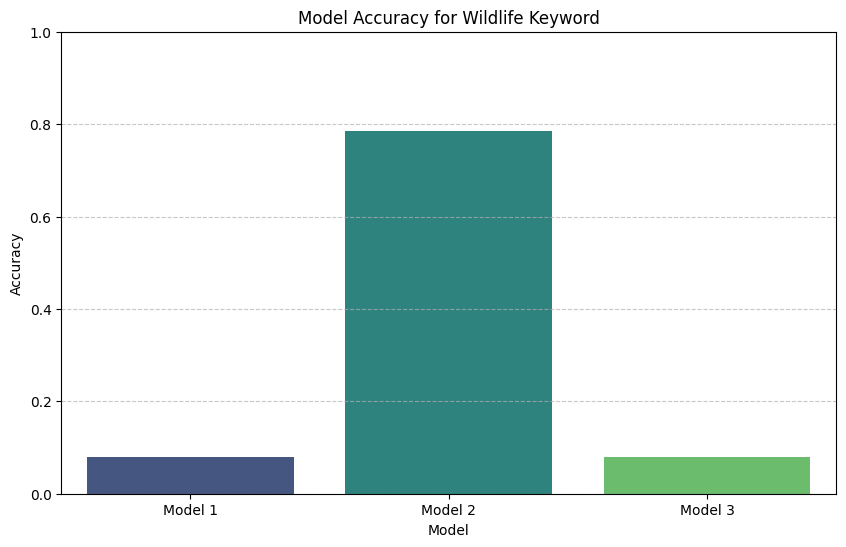

Generated bar chart for model accuracy.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy for Wildlife Keyword')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Generated bar chart for model accuracy.")

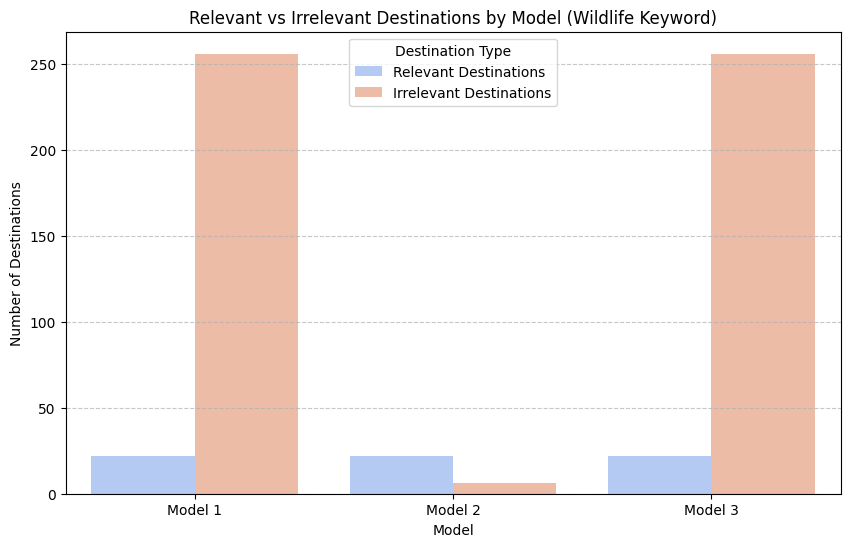

Generated stacked bar chart for relevant vs irrelevant destinations.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
# Create a DataFrame for plotting, using `accuracy_df`
plot_df = accuracy_df[['Model', 'Relevant Destinations', 'Irrelevant Destinations']]

# Melt the DataFrame to a long format for seaborn
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Destination Type', value_name='Count')

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Destination Type', data=plot_df_melted, palette='coolwarm')

plt.title('Relevant vs Irrelevant Destinations by Model (Wildlife Keyword)')
plt.xlabel('Model')
plt.ylabel('Number of Destinations')
plt.legend(title='Destination Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Generated stacked bar chart for relevant vs irrelevant destinations.")

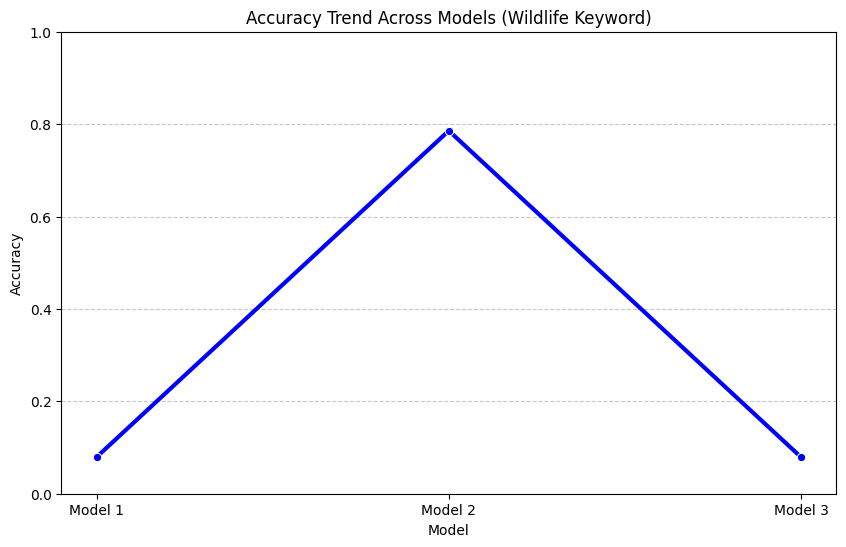

Generated line plot for accuracy trend.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot for Accuracy Trend
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=accuracy_df, marker='o', linewidth=3, color='blue') # Removed hue='Model' and added linewidth
plt.title('Accuracy Trend Across Models (Wildlife Keyword)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Model') # Legend is not needed for a single line
plt.show()

print("Generated line plot for accuracy trend.")

## Create Accuracy Data for 'Adventure' Keyword

### Subtask:
Generate the `accuracy_df` DataFrame by evaluating Model 1, Model 2, and Model 3 solely for the input condition `keyword='Adventure'`. This will involve calling the model functions, calculating `Weather_Suitability`, and then determining 'Accuracy', 'Relevant Destinations', and 'Irrelevant Destinations' for this specific input, storing the results in a new DataFrame named `accuracy_df`.


In [ ]:
import pandas as pd

# 1. Initialize an empty list to store results
results = []

# 2. Define a dictionary of models
models = {
    'Model 1': recommend_destinations,
    'Model 2': model_temp_humidity_windspeed_filter,
    'Model 3': model_weighted_scoring
}

# 3. Define the input condition and R_threshold
input_condition = {'type': 'keyword', 'value': 'Adventure'}
R_threshold = 4.0

# Loop through each model
for model_name, model_func in models.items():
    print(f"Evaluating {model_name} for {input_condition['type']}={input_condition['value']}...")

    # a. Call the current model function
    model_output_df = model_func(keyword=input_condition['value'])

    # b. Create a copy of the output DataFrame
    # calculate_accuracy already makes a copy and handles Weather_Suitability if not present
    temp_df = model_output_df.copy()

    # c. Calculate the accuracy of the model's output
    accuracy = calculate_accuracy(temp_df, R_threshold)

    # d. Ensure 'Weather_Suitability' column exists for relevance calculation
    # calculate_accuracy function should have already added this if not present
    if 'Weather_Suitability' not in temp_df.columns:
        temp_df['Weather_Suitability'] = temp_df.apply(
            lambda row: calculate_weather_suitability(
                row['Temperature'], row['Humidity'], row['Wind speed']
            ), axis=1
        )

    # e. Apply calculate_relevance to create 'Relevance' column
    temp_df['Relevance'] = temp_df.apply(
        lambda row: calculate_relevance(
            row['google_rating'], row['Weather_Suitability'], R_threshold
        ), axis=1
    )

    # f. Count relevant and irrelevant destinations
    relevant_destinations = temp_df['Relevance'].sum()
    irrelevant_destinations = len(temp_df) - relevant_destinations

    # g. Append results
    results.append({
        'Model': model_name,
        'Input Condition': f"{input_condition['type'].capitalize()}={input_condition['value']}",
        'Accuracy': accuracy,
        'Relevant Destinations': relevant_destinations,
        'Irrelevant Destinations': irrelevant_destinations
    })

# 5. Convert the results list into a Pandas DataFrame
accuracy_df = pd.DataFrame(results)

# 6. Print the accuracy_df DataFrame
print("\nAccuracy DataFrame:")
print(accuracy_df)

NameError: name 'recommend_destinations' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy for Adventure Keyword')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Generated bar chart for model accuracy.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
# Create a DataFrame for plotting, using `accuracy_df`
plot_df = accuracy_df[['Model', 'Relevant Destinations', 'Irrelevant Destinations']]

# Melt the DataFrame to a long format for seaborn
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Destination Type', value_name='Count')

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Destination Type', data=plot_df_melted, palette='coolwarm')

plt.title('Relevant vs Irrelevant Destinations by Model (Adventure Keyword)')
plt.xlabel('Model')
plt.ylabel('Number of Destinations')
plt.legend(title='Destination Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Generated stacked bar chart for relevant vs irrelevant destinations.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot for Accuracy Trend
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=accuracy_df, marker='o', linewidth=3, color='blue') # Removed hue='Model' and added linewidth
plt.title('Accuracy Trend Across Models (Adventure Keyword)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Model') # Legend is not needed for a single line
plt.show()

print("Generated line plot for accuracy trend.")